In [2]:
from xgboost import XGBClassifier, XGBModel
import xgboost as xgb 
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

In [3]:
loan = pd.read_csv(os.path.abspath(os.path.join(os.getcwd() + '\\..\\data\\train_loanpred.csv')))
tree_loan = loan.loc[:, ~loan.columns.isin(["Loan_ID"])]
print(tree_loan.shape)

(614, 12)


In [4]:
tree_loan["Loan_Status"].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [5]:
loan_test = pd.read_csv(os.path.abspath(os.path.join(os.getcwd() + '\\..\\data\\test_loanpred.csv')))
x_test = loan_test.loc[:, ~loan_test.columns.isin(["Loan_ID"])]
print(x_test.shape)

(367, 11)


In [6]:
tree_loan.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0,141.0,360.0,1.0,Urban,Y


In [7]:
tree_loan.isnull().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
X = tree_loan.iloc[:, :-1]
Y = tree_loan.iloc[:, -1]
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=22)

# Native handling of missing values - No imputation

In [9]:
cat_cols = ["Property_Area", "Dependents", "Gender", "Married", "Education", "Self_Employed"]

In [10]:
for col in cat_cols: 
    x_train[col] = x_train[col].astype('category')
    x_val[col] =  x_val[col].astype('category')
    x_test[col] = x_test[col].astype('category')

C:\Users\nedwi\AppData\Local\Temp\ipykernel_32068\1117333741.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = x_test[col].astype('category')
C:\Users\nedwi\AppData\Local\Temp\ipykernel_32068\1117333741.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = x_test[col].astype('category')
C:\Users\nedwi\AppData\Local\Temp\ipykernel_32068\1117333741.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [11]:
x_train.dtypes

Gender               category
Married              category
Dependents           category
Education            category
Self_Employed        category
ApplicantIncome         int64
CoapplicantIncome       int64
LoanAmount            float64
Loan_Amount_Term      float64
Credit_History        float64
Property_Area        category
dtype: object

In [12]:
y_train_mapped = y_train.map(lambda x: 1 if x == 'Y' else 0)
y_val_mapped = y_val.map(lambda x: 1 if x == 'Y' else 0)

## model trained with default params

In [19]:
model = XGBClassifier(enable_categorical=True) 
model.fit(x_train, y_train_mapped)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [20]:
pred = model.predict(x_val)
accuracy_score(y_val_mapped, pred)

0.7154471544715447

In [21]:
pos_val = y_train_mapped[y_train_mapped == 0].shape[0]/ y_train_mapped[y_train_mapped == 1].shape[0]
pos_val

0.4526627218934911

## model trained with manual params

In [14]:
xgb_model = XGBClassifier(n_estimators=500, 
                    base_score=0.5,
                    early_stopping_rounds=20, 
                    learning_rate = 0.1,
                    subsample = 0.8,
                    max_depth=3,
                    tree_method = 'auto', #hist
                    max_bin = 256,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    gamma=0.1,
                    reg_alpha = 0,
                    reg_lambda = 1,
                    enable_categorical=True,
                    missing=np.nan,
                    #scale_pos_weight=pos_val,
                    callbacks= [xgb.callback.EvaluationMonitor()], #verbose=True in sklearn API ≈ EvaluationMonitor()
                    random_state=42
                    )

xgb_model.fit(x_train, y_train_mapped, eval_set=[(x_train, y_train_mapped), (x_val,y_val_mapped)], verbose=True)
#dont use testing data in eval

[0]	validation_0-logloss:0.65479	validation_1-logloss:0.65685
[0]	validation_0-logloss:0.65479	validation_1-logloss:0.65685
[1]	validation_0-logloss:0.62304	validation_1-logloss:0.62757
[1]	validation_0-logloss:0.62304	validation_1-logloss:0.62757
[2]	validation_0-logloss:0.59601	validation_1-logloss:0.60237
[2]	validation_0-logloss:0.59601	validation_1-logloss:0.60237
[3]	validation_0-logloss:0.57300	validation_1-logloss:0.58103
[3]	validation_0-logloss:0.57300	validation_1-logloss:0.58103
[4]	validation_0-logloss:0.55411	validation_1-logloss:0.56237
[4]	validation_0-logloss:0.55411	validation_1-logloss:0.56237
[5]	validation_0-logloss:0.53813	validation_1-logloss:0.54571
[5]	validation_0-logloss:0.53813	validation_1-logloss:0.54571
[6]	validation_0-logloss:0.52416	validation_1-logloss:0.53115
[6]	validation_0-logloss:0.52416	validation_1-logloss:0.53115
[7]	validation_0-logloss:0.51159	validation_1-logloss:0.52103
[7]	validation_0-logloss:0.51159	validation_1-logloss:0.52103
[8]	vali

,objective,'binary:logistic'
,base_score,0.5
,booster,None
,callbacks,[<xgboost.call...002CC9AA88190>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,20
,enable_categorical,True
,eval_metric,'logloss'


In [15]:
print(f'Best iteration is {xgb_model.best_iteration} and \
   \n trainging best score is {xgb_model.evals_result()["validation_0"]["logloss"][xgb_model.best_iteration]} \
    \n validation best score is {xgb_model.best_score} after early stopping')

Best iteration is 45 and    
 trainging best score is 0.3697728935151139     
 validation best score is 0.44882087167201 after early stopping


In [24]:
xgb_pred = xgb_model.predict(x_val)
accuracy_score(y_val_mapped, xgb_pred)

0.8048780487804879

## model trained using cross-validation

In [25]:
#rreturns the average performance across all folds at each step of training
dtrain = xgb.DMatrix(x_train, label=y_train_mapped, enable_categorical=True) 
params = { 
                    #'n_estimators':500, 
                    'base_score':0.5,
                    #'early_stopping_rounds':20, 
                    'learning_rate': 0.1,
                    'subsample' : 0.8,
                    'max_depth':3,
                    'tree_method' : 'auto', #hist
                    'max_bin' :256,
                    'objective':"binary:logistic",
                    'eval_metric':"logloss",
                    'gamma':0.1,
                    'reg_alpha': 0,
                    'reg_lambda': 1,
                    'missing': np.nan,
                    'enable_categorical':True,
         }
cv_results = xgb.cv( params, dtrain, num_boost_round=1000, nfold=5, early_stopping_rounds=20, seed=42 )
cv_results

C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:225: UserWarning: [11:38:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "enable_categorical", "missing" } are not used.

  return getattr(self.bst, name)(*args, **kwargs)
C:\Users\nedwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:231: UserWarning: [11:38:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "enable_categorical", "missing" } are not used.

  self.bst.update(self.dtrain, iteration, fobj)


,train-logloss-mean,train-logloss-std,test-logloss-mean,test-logloss-std
0,0.653714,0.002339,0.657214,0.005023
1,0.622883,0.004325,0.630270,0.009954
2,0.597019,0.006709,0.609193,0.015009
3,0.573857,0.008034,0.588795,0.019070
4,0.554628,0.009049,0.572168,0.022841
5,0.537200,0.009935,0.558697,0.026405
6,0.523362,0.010597,0.547881,0.029770
7,0.510387,0.011149,0.538716,0.033247
8,0.498933,0.011704,0.532234,0.036683
9,0.489658,0.012502,0.526070,0.039213


In [26]:
print(cv_results["test-logloss-mean"].argmin())
print(cv_results['test-logloss-mean'].iloc[-1])

21
0.4952144360539532


In [27]:
best_num_boost_round = len(cv_results)
best_num_boost_round

22

### model trained using best early stopping params from CV results

In [ ]:
XGBModel(

In [28]:
xgb_clf = XGBClassifier( n_estimators=best_num_boost_round, **params, importance_type='gain' ) 
xgb_clf.fit(x_train, y_train_mapped) 
y_test_preds = xgb_clf.predict(x_val)
y_train_preds = xgb_clf.predict(x_train)

In [29]:
accuracy_score(y_val_mapped, y_test_preds)

0.8292682926829268

In [30]:
xgb_clf.predict_proba(x_val)

array([[0.18781495, 0.81218505],
       [0.18967777, 0.8103222 ],
       [0.19346595, 0.80653405],
       [0.38436383, 0.61563617],
       [0.28319502, 0.716805  ],
       [0.7908009 , 0.2091991 ],
       [0.21572411, 0.7842759 ],
       [0.2122761 , 0.7877239 ],
       [0.19260383, 0.8073962 ],
       [0.9120532 , 0.08794679],
       [0.2049352 , 0.7950648 ],
       [0.2521987 , 0.7478013 ],
       [0.9211765 , 0.07882353],
       [0.18994993, 0.8100501 ],
       [0.18320239, 0.8167976 ],
       [0.79631513, 0.20368485],
       [0.19666487, 0.80333513],
       [0.2636553 , 0.7363447 ],
       [0.36028296, 0.63971704],
       [0.24199808, 0.7580019 ],
       [0.3024463 , 0.6975537 ],
       [0.19140875, 0.80859125],
       [0.13825303, 0.86174697],
       [0.25305563, 0.74694437],
       [0.26273996, 0.73726004],
       [0.2638198 , 0.7361802 ],
       [0.31056494, 0.68943506],
       [0.19650519, 0.8034948 ],
       [0.6014185 , 0.39858148],
       [0.1574384 , 0.8425616 ],
       [0.

In [338]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb_clf, x_train, y_train_mapped, cv=5, scoring='accuracy')

print(f"Scores: {scores}")
print(f"Mean Score: {scores.mean()}")

Scores: [0.76767677 0.78571429 0.80612245 0.80612245 0.82653061]
Mean Score: 0.7984333127190271


## feature importance

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

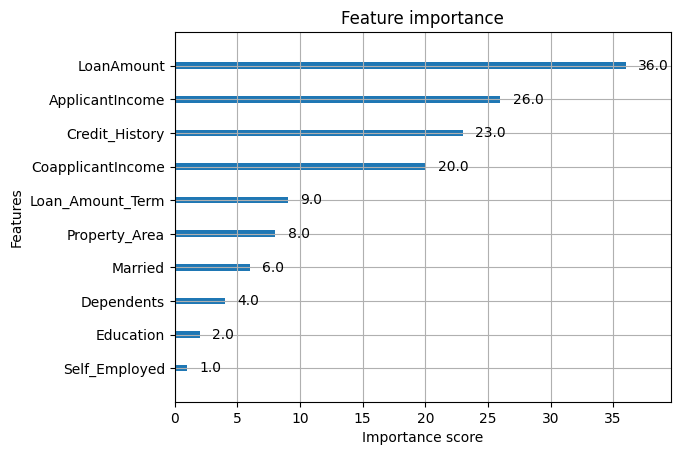

In [211]:
# Feature importance based on weight
from xgboost import plot_importance
plot_importance(xgb_clf)

<Axes: xlabel='Importance', ylabel='Feature'>

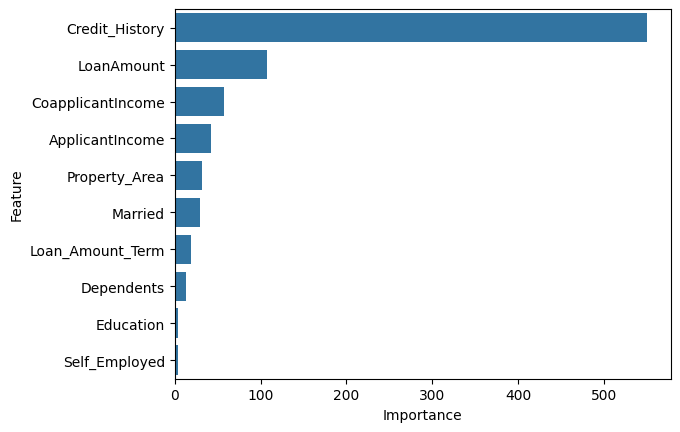

In [280]:
total_gain_dic = xgb_clf.get_booster().get_score(importance_type='total_gain')
total_gain = pd.DataFrame(total_gain_dic, index=[0]).T
total_gain = total_gain.reset_index().rename(columns={"index":"Feature", 0: "Importance"})
total_gain.sort_values(by='Importance', ascending=False, inplace=True)
sns.barplot(x=total_gain.Importance, y=total_gain.Feature)

In [253]:
xgb_clf.get_booster().get_score(importance_type='gain')

{'Married': 4.8287529945373535,
 'Dependents': 3.2348103523254395,
 'Education': 2.166409969329834,
 'Self_Employed': 3.4486494064331055,
 'ApplicantIncome': 1.6048043966293335,
 'CoapplicantIncome': 2.867013454437256,
 'LoanAmount': 2.975513458251953,
 'Loan_Amount_Term': 2.1157445907592773,
 'Credit_History': 23.93639373779297,
 'Property_Area': 3.941206216812134}

<Axes: xlabel='Importance', ylabel='Feature'>

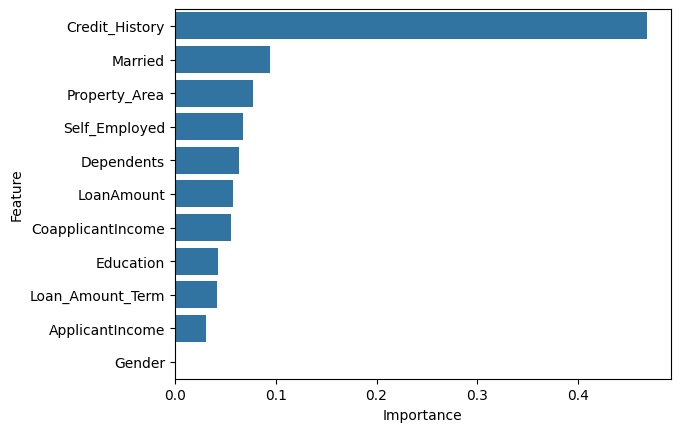

In [212]:
#Feature importance based on gain - if importance type is default in model.
feature_names = x_train.columns
importance = xgb_clf.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
sns.barplot(x=feature_importance_df.Importance, y=feature_importance_df.Feature)

In [75]:
pred = xgb.predict(x_test)

In [ ]:
x_cat= pd.get_dummies(x_train[cat_cols], drop_first=True)
x_val_cat = pd.get_dummies(x_val[cat_cols], drop_first=True)
x_val_cat = x_val_cat.reindex(columns=x_cat.columns, fill_value=0)
